In [2]:
import pandas as pd 

In [3]:
# Loading the pre cleaned data from sql with important key features
df= pd.read_csv('/Users/prashantsinghchauhan/Downloads/GA_/Capstone/weighted_churn.csv')

In [4]:
# some basic checks 
df.shape

(7043, 8)

In [5]:
df.dtypes

customerID             str
MonthlyCharges     float64
tenure               int64
contract               str
InternetService        str
churn                  str
risk_score           int64
category               str
dtype: object

In [6]:
df.isnull().sum()

customerID         0
MonthlyCharges     0
tenure             0
contract           0
InternetService    0
churn              0
risk_score         0
category           0
dtype: int64

In [6]:

# features for clustering 
features = ['MonthlyCharges', 'tenure', 'contract', 'InternetService', 'risk_score']
X = df[features]

# One-Hot Encoding for some categorical variables

X_encoded = pd.get_dummies(X, columns=['contract', 'InternetService'], drop_first=True)

print(X_encoded.head())

   MonthlyCharges  tenure  risk_score  contract_One year  contract_Two year  \
0            65.6       9          55               True              False   
1            59.9       9          65              False              False   
2            73.9       4          90              False              False   
3            98.0      13          80              False              False   
4            83.9       3          85              False              False   

   InternetService_Fiber optic  InternetService_No  
0                        False               False  
1                        False               False  
2                         True               False  
3                         True               False  
4                         True               False  


In [11]:
#scale the data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
scaled_features = scaler.fit_transform(X_encoded)

k_means = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
df['Cluster'] = k_means.fit_predict(scaled_features)


In [12]:
df.groupby('Cluster')[['MonthlyCharges', 'tenure']].mean()

,MonthlyCharges,tenure
Cluster,,
0,89.400225,27.726387
1,42.777881,21.586721
2,60.749292,56.754427


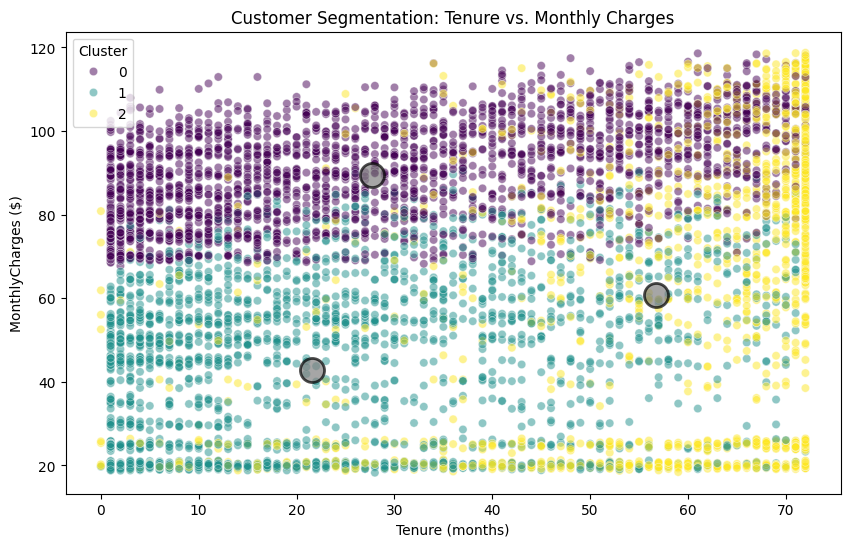

In [11]:
# centroids 
centroids = k_means.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids)


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Cluster', palette='viridis', alpha=0.5)
plt.title('Customer Segmentation: Tenure vs. Monthly Charges')
plt.scatter(centroids_orig[:, 1], centroids_orig[:, 0], s=300, c='gray', marker='o', edgecolors='black', linewidth=2, label='Centroids', alpha= 0.7)
plt.ylabel('MonthlyCharges ($)')
plt.xlabel('Tenure (months)')
plt.show()




Text(0, 0.5, 'Monthly Charges ($)')

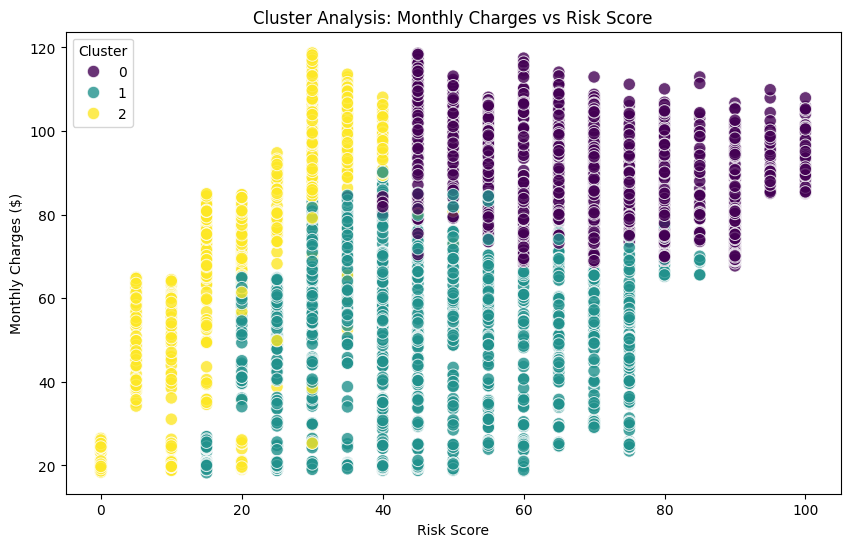

In [13]:
# let's reduce the noise a little more by using risk score to know cluster of group that might churn. 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='risk_score', y='MonthlyCharges', 
                hue='Cluster', palette='viridis', s=80, alpha=0.8)
plt.title('Cluster Analysis: Monthly Charges vs Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Monthly Charges ($)')

In [ ]:
# so any customer who has a risk score of above 40 and has been paying more than $70 is our premium customer with high retention priority as they might churn. 

In [20]:
# now extracting the cluster 0 as it is the most important customer ( premium customers) for performing churn analysis. 

priority_retention = df[df['Cluster'] == 0]
priority_retention.to_csv('priority_retention.csv', index = False)
